# Line segmentation

In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Output
import ipywidgets as widgets

print("✓ All imports successful!")

# ========= CONFIG =========
image_path = r"data\PORCONES_228_38_1646\cropped\page_007.png"  # Create directories
output_base = r"data\PORCONES_228_38_1646"
os.makedirs(output_base, exist_ok=True)
os.makedirs(f"{output_base}/lines", exist_ok=True)
os.makedirs(f"{output_base}/visualizations", exist_ok=True)

print(f"Working directory: {os.getcwd()}")
print(f"Image path: {image_path}")

# ========= LOAD IMAGE =========
print("\n📁 Loading image...")

if not os.path.exists(image_path):
    print(f"❌ File not found: {image_path}")
    exit()

img = cv2.imread(image_path)

if img is None:
    print(f"❌ Cannot read image: {image_path}")
    exit()

print(f"✓ Image loaded: {img.shape}")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(f"✓ Converted to grayscale: {gray.shape}")

# ========= PREPROCESS =========
print("\n🔄 Preprocessing...")

# Use Otsu's thresholding
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print("✓ Preprocessing complete")

# Store globally for use in interactive function
current_lines = []
current_hist = None

print("\n✓ Ready for interactive parameter tuning!")

✓ All imports successful!
Working directory: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\notebooks
Image path: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646\cropped\page_007.png

📁 Loading image...
✓ Image loaded: (8064, 3435, 3)
✓ Converted to grayscale: (8064, 3435)

🔄 Preprocessing...
✓ Preprocessing complete

✓ Ready for interactive parameter tuning!


In [ ]:
def projection_method_interactive(threshold_percent=0.10, min_gap=5, min_line_height=5):
    """
    Interactive projection method with adjustable parameters
    
    Args:
        threshold_percent: Threshold as percentage of max (0.01-0.30)
        min_gap: Minimum gap between lines in pixels (1-20)
        min_line_height: Minimum line height in pixels (1-50)
    """
    global current_lines, current_hist, img, gray, thresh, output_base
    
    # Calculate horizontal projection
    hist = np.sum(thresh, axis=1)
    current_hist = hist
    
    # Find threshold
    max_hist = np.max(hist)
    if max_hist == 0:
        print("❌ Empty image")
        return [], hist
    
    threshold = max_hist * threshold_percent
    
    lines = []
    start = None
    
    # Find continuous regions with text
    for i, val in enumerate(hist):
        if val > threshold and start is None:
            start = i
        elif val <= threshold and start is not None:
            # Check minimum gap
            gap = i - start
            if gap >= min_line_height:
                lines.append((start, i))
            start = None
    
    # Don't forget last line
    if start is not None:
        last_gap = len(hist) - start
        if last_gap >= min_line_height:
            lines.append((start, len(hist)))
    
    # Merge nearby lines if needed
    if min_gap > 1:
        merged_lines = []
        for y_start, y_end in lines:
            if merged_lines and y_start - merged_lines[-1][1] < min_gap:
                # Merge with previous
                merged_lines[-1] = (merged_lines[-1][0], y_end)
            else:
                merged_lines.append((y_start, y_end))
        lines = merged_lines
    
    current_lines = lines
    
    return lines, hist



def visualize_projection(threshold_percent=0.10, min_gap=5, min_line_height=5):
    """Visualize projection method with current parameters"""
    global current_lines, current_hist, img, thresh
    
    lines, hist = projection_method_interactive(threshold_percent, min_gap, min_line_height)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.suptitle('Projection-Based Line Detection - Interactive Parameter Tuning', 
                 fontsize=14, fontweight='bold')
    
    # 1. Original image with detected lines
    ax = axes[0]
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    
    for i, (y1, y2) in enumerate(lines):
        cv2.rectangle(img_display, (0, int(y1)), (img_display.shape[1], int(y2)), 
                     (0, 255, 0), 2)
        cv2.putText(img_display, str(i+1), (20, int((y1+y2)//2)), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    
    ax.imshow(img_display)
    ax.set_title(f'Detected Lines: {len(lines)}', fontsize=12, fontweight='bold')
    ax.axis('on')
    
    # 2. Horizontal projection
    ax = axes[1]
    ax.plot(hist, range(len(hist)), linewidth=2, color='#3498db')
    ax.fill_betweenx(range(len(hist)), 0, hist, alpha=0.3, color='#3498db')
    
    # Mark threshold line
    max_hist = np.max(hist)
    threshold = max_hist * threshold_percent
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
              label=f'Threshold ({threshold_percent:.1%})')
    
    # Mark line boundaries
    for y1, y2 in lines:
        ax.axhline(y=y1, color='green', linestyle='--', alpha=0.3, linewidth=0.8)
        ax.axhline(y=y2, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
    
    ax.set_title('Horizontal Projection Profile', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Count', fontsize=10)
    ax.set_ylabel('Row Number', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.legend()
    
    # 3. Statistics
    ax = axes[2]
    ax.axis('off')
    
    if lines:
        heights = np.array([y2 - y1 for y1, y2 in lines])
        stats_text = f"""
DETECTION PARAMETERS
{'='*35}

Threshold:      {threshold_percent:.1%}
Min Gap:        {min_gap} px
Min Height:     {min_line_height} px

RESULTS
{'='*35}

Lines Detected: {len(lines)}
Avg Height:     {np.mean(heights):.1f} px
Min Height:     {np.min(heights):.0f} px
Max Height:     {np.max(heights):.0f} px
Std Dev:        {np.std(heights):.1f} px

Total Text:     {np.sum(heights):.0f} px
Page Height:    {img.shape[0]} px
Coverage:       {(np.sum(heights)/img.shape[0]*100):.1f}%
        """
    else:
        stats_text = """
NO LINES DETECTED

Try:
• Lower threshold
• Reduce min_height
• Adjust min_gap
        """
    
    ax.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
           verticalalignment='center', bbox=dict(boxstyle='round',
           facecolor='#ecf0f1', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

print("✓ Visualization function created")

✓ Visualization function created


In [ ]:
from ipywidgets import VBox, HBox
import ipywidgets as widgets

print("\n" + "="*70)
print("INTERACTIVE PARAMETER TUNING")
print("="*70)
print("\nAdjust the sliders below to find optimal parameters")
print("The visualization will update in real-time\n")

# Create sliders
threshold_slider = FloatSlider(
    min=0.01, max=0.50, step=0.01, value=0.10,
    description='Threshold %:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

min_gap_slider = IntSlider(
    min=1, max=20, step=1, value=5,
    description='Min Gap (px):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

min_height_slider = IntSlider(
    min=1, max=50, step=1, value=5,
    description='Min Height (px):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

# Create output widget
output_widget = Output()

def update_visualization(change=None):
    """Update visualization when sliders change"""
    output_widget.clear_output(wait=True)
    with output_widget:
        visualize_projection(
            threshold_slider.value,
            min_gap_slider.value,
            min_height_slider.value
        )

# Connect sliders to update function
threshold_slider.observe(update_visualization, names='value')
min_gap_slider.observe(update_visualization, names='value')
min_height_slider.observe(update_visualization, names='value')

# Display sliders and output
print("SLIDERS:")
display(VBox([threshold_slider, min_gap_slider, min_height_slider]))

print("\nVISUALIZATION:")
display(output_widget)

# Show initial visualization
update_visualization()


INTERACTIVE PARAMETER TUNING

Adjust the sliders below to find optimal parameters
The visualization will update in real-time

SLIDERS:



VISUALIZATION:


Output()

In [4]:
# After tuning parameters above, set your optimal values here
optimal_threshold = 0.17  # ← CHANGE THIS
optimal_min_gap = 5       # ← CHANGE THIS
optimal_min_height = 9   # ← CHANGE THIS

print(f"\n✓ Optimal parameters selected:")
print(f"  Threshold:      {optimal_threshold:.1%}")
print(f"  Min Gap:        {optimal_min_gap} px")
print(f"  Min Height:     {optimal_min_height} px")


✓ Optimal parameters selected:
  Threshold:      17.0%
  Min Gap:        5 px
  Min Height:     9 px


In [ ]:
import json
from datetime import datetime

print("\n" + "="*70)
print("SAVING LINES WITH OPTIMAL PARAMETERS")
print("="*70)

# Detect lines with optimal parameters
optimal_lines, optimal_hist = projection_method_interactive(
    threshold_percent=optimal_threshold,
    min_gap=optimal_min_gap,
    min_line_height=optimal_min_height
)

print(f"\n📊 Detected {len(optimal_lines)} lines with optimal parameters")

# Create output directories
output_lines_dir = Path(output_base) / "lines"
output_lines_dir.mkdir(exist_ok=True, parents=True)

metadata_dir = Path(output_base) / "metadata"
metadata_dir.mkdir(exist_ok=True, parents=True)

# Save each line image
print("\n💾 Saving line images...")

saved_count = 0
for idx, (y1, y2) in enumerate(optimal_lines):
    try:
        if y2 > y1:
            # Crop line
            line_img = img[int(y1):int(y2), :]
            
            # Normalize height
            target_height = 64
            current_height = line_img.shape[0]
            ratio = target_height / current_height
            new_width = int(line_img.shape[1] * ratio)
            
            line_img_normalized = cv2.resize(line_img, (new_width, target_height),
                                            interpolation=cv2.INTER_CUBIC)
            
            # Pad to standard width
            if line_img_normalized.shape[1] < 1024:
                pad_right = 1024 - line_img_normalized.shape[1]
                line_img_normalized = cv2.copyMakeBorder(
                    line_img_normalized, 0, 0, 0, pad_right,
                    cv2.BORDER_CONSTANT, value=255
                )
            else:
                line_img_normalized = line_img_normalized[:, :1024]
            
            # Save image
            img_filename = f"line_{idx:04d}.png"
            img_path = output_lines_dir / img_filename
            cv2.imwrite(str(img_path), line_img_normalized)
            
            # Create metadata
            metadata = {
                'line_number': idx + 1,
                'original_y_start': int(y1),
                'original_y_end': int(y2),
                'original_height': int(y2 - y1),
                'normalized_size': [target_height, 1024],
                'image_file': img_filename,
                'source_page': Path(image_path).name,
                'created_at': datetime.now().isoformat(),
                'parameters': {
                    'threshold': optimal_threshold,
                    'min_gap': optimal_min_gap,
                    'min_line_height': optimal_min_height
                }
            }
            
            # Save metadata
            meta_filename = f"line_{idx:04d}.json"
            meta_path = metadata_dir / meta_filename
            with open(meta_path, 'w') as f:
                json.dump(metadata, f, indent=2)
            
            saved_count += 1
            
            if (idx + 1) % 5 == 0:
                print(f"  ✓ Saved {idx + 1} lines...")
    
    except Exception as e:
        print(f"  ❌ Error saving line {idx}: {e}")

print(f"\n✓ Successfully saved {saved_count} lines!")

# Create dataset summary
summary = {
    'source_image': {
        'filename': Path(image_path).name,
        'path': str(image_path),
        'size': [img.shape[1], img.shape[0]],
        'processed_at': datetime.now().isoformat()
    },
    'detection_method': 'projection',
    'parameters': {
        'threshold_percent': optimal_threshold,
        'min_gap': optimal_min_gap,
        'min_line_height': optimal_min_height
    },
    'results': {
        'total_lines': len(optimal_lines),
        'line_dimensions': [64, 1024],
        'format': 'PNG',
        'output_directory': str(output_lines_dir)
    },
    'statistics': {
        'heights': [int(y2 - y1) for y1, y2 in optimal_lines],
        'avg_height': float(np.mean([y2 - y1 for y1, y2 in optimal_lines])),
        'coverage_percent': float((sum([y2 - y1 for y1, y2 in optimal_lines]) / img.shape[0]) * 100)
    }
}

summary_path = Path(output_base) / "dataset_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Summary saved to {summary_path}")


SAVING LINES WITH OPTIMAL PARAMETERS

📊 Detected 35 lines with optimal parameters

💾 Saving line images...
  ✓ Saved 5 lines...
  ✓ Saved 10 lines...
  ✓ Saved 15 lines...
  ✓ Saved 20 lines...
  ✓ Saved 25 lines...
  ✓ Saved 30 lines...
  ✓ Saved 35 lines...

✓ Successfully saved 35 lines!
✓ Summary saved to C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646\dataset_summary.json



DISPLAYING SAVED LINE SAMPLES


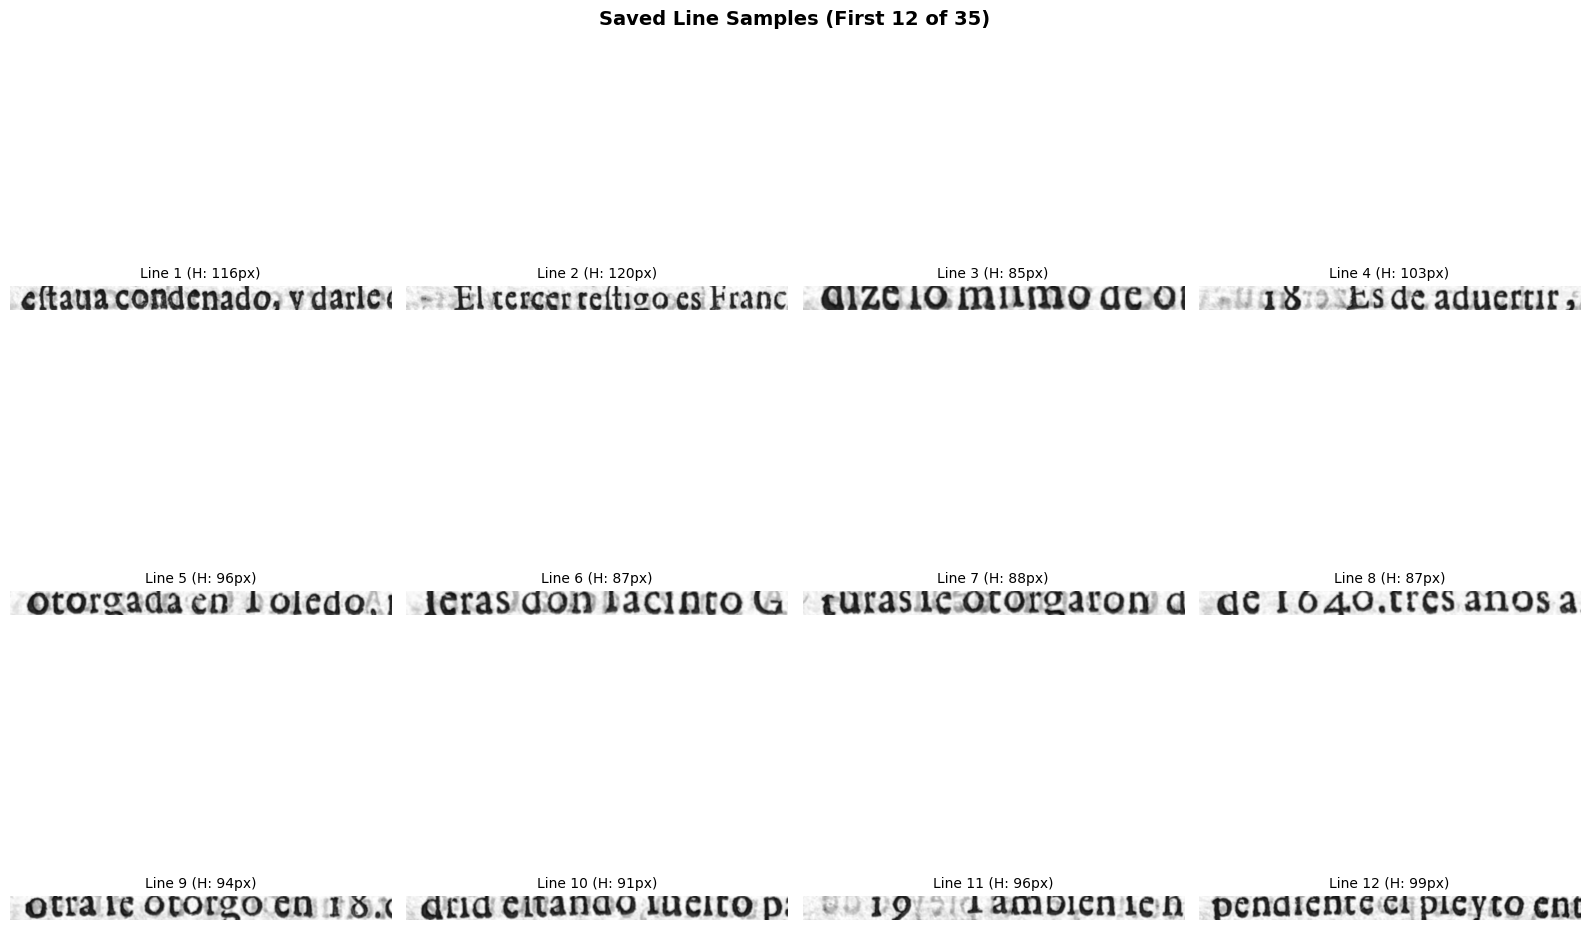

✓ Visualization saved


In [ ]:
print("\n" + "="*70)
print("DISPLAYING SAVED LINE SAMPLES")
print("="*70)

# Show first 12 lines
num_display = min(12, len(optimal_lines))
cols = 4
rows = (num_display + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

fig.suptitle(f'Saved Line Samples (First {num_display} of {len(optimal_lines)})',
            fontsize=14, fontweight='bold')

for idx in range(num_display):
    y1, y2 = optimal_lines[idx]
    
    # Load saved normalized image
    line_path = output_lines_dir / f"line_{idx:04d}.png"
    line_img = cv2.imread(str(line_path))
    
    axes[idx].imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"Line {idx+1} (H: {int(y2-y1)}px)", fontsize=10)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(num_display, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f"{output_base}/visualizations/saved_lines_sample.png", dpi=100, bbox_inches='tight')
plt.show()

print("✓ Visualization saved")

In [ ]:
print("\n" + "="*70)
print("PROJECTION METHOD - FINAL SUMMARY")
print("="*70)

heights = np.array([y2 - y1 for y1, y2 in optimal_lines])

print(f"""
📊 PARAMETERS USED:
  • Threshold:          {optimal_threshold:.1%}
  • Min Gap:            {optimal_min_gap} px
  • Min Line Height:    {optimal_min_height} px

✅ RESULTS:
  • Total Lines:        {len(optimal_lines)}
  • Avg Height:         {np.mean(heights):.1f} px
  • Height Range:       {np.min(heights):.0f} - {np.max(heights):.0f} px
  • Std Deviation:      {np.std(heights):.1f} px
  • Page Coverage:      {(np.sum(heights)/img.shape[0]*100):.1f}%

📁 OUTPUT LOCATION:
  {output_base}/
  ├── lines/              ({len(optimal_lines)} PNG images)
  ├── metadata/           ({len(optimal_lines)} JSON files)
  ├── visualizations/     (Comparison images)
  └── dataset_summary.json

💾 FILES CREATED:
  • Line images:        {len(optimal_lines)} × line_0000-line_{len(optimal_lines)-1:04d}.png
  • Metadata files:     {len(optimal_lines)} × line_0000-line_{len(optimal_lines)-1:04d}.json
  • Summary file:       dataset_summary.json
  • Total size:         ~{(len(optimal_lines) * 64 * 1024) / (1024*1024):.1f} MB

🎯 NEXT STEPS:
  1. Review lines in {output_base}/lines/
  2. Check metadata in {output_base}/metadata/
  3. Use this dataset for training
  4. Adjust parameters if needed
  5. Process more pages using same parameters

✓ Complete! Dataset ready for use.
""")


PROJECTION METHOD - FINAL SUMMARY

📊 PARAMETERS USED:
  • Threshold:          17.0%
  • Min Gap:            5 px
  • Min Line Height:    9 px

✅ RESULTS:
  • Total Lines:        35
  • Avg Height:         97.6 px
  • Height Range:       15 - 127 px
  • Std Deviation:      17.8 px
  • Page Coverage:      42.3%

📁 OUTPUT LOCATION:
  C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646/
  ├── lines/              (35 PNG images)
  ├── metadata/           (35 JSON files)
  ├── visualizations/     (Comparison images)
  └── dataset_summary.json

💾 FILES CREATED:
  • Line images:        35 × line_0000-line_0034.png
  • Metadata files:     35 × line_0000-line_0034.json
  • Summary file:       dataset_summary.json
  • Total size:         ~2.2 MB

🎯 NEXT STEPS:
  1. Review lines in C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646/lines/
  2. Check metadata in C:\Open Source\G

# Cropping lines - Part 2

In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from ipywidgets import interact, FloatSlider, IntSlider, Output, Button, VBox, HBox
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
from datetime import datetime

print("✓ All imports successful!")

# ========= CONFIG =========
image_path = r"data\PORCONES_228_38_1646\cropped\page_007.png"
output_base = r"data\PORCONES_228_38_1646\crop_output"

# Create directories
os.makedirs(output_base, exist_ok=True)
os.makedirs(f"{output_base}/lines", exist_ok=True)
os.makedirs(f"{output_base}/metadata", exist_ok=True)
os.makedirs(f"{output_base}/visualizations", exist_ok=True)

print(f"Working directory: {os.getcwd()}")
print(f"Image path: {image_path}")

# ========= LOAD IMAGE =========
print("\n📁 Loading image...")

if not os.path.exists(image_path):
    print(f"❌ File not found: {image_path}")
    exit()

img = cv2.imread(image_path)

if img is None:
    print(f"❌ Cannot read image: {image_path}")
    exit()

print(f"✓ Image loaded: {img.shape}")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ========= PREPROCESS =========
print("\n🔄 Preprocessing...")

_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print("✓ Preprocessing complete")

# Store globally
current_lines = []
current_hist = None
selected_lines = []

print("\n✓ Ready for interactive line cropping!")

✓ All imports successful!
Working directory: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\notebooks
Image path: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646\cropped\page_007.png

📁 Loading image...
✓ Image loaded: (8064, 3435, 3)

🔄 Preprocessing...
✓ Preprocessing complete

✓ Ready for interactive line cropping!


In [ ]:
def projection_method_interactive(threshold_percent=0.10, min_gap=5, min_line_height=5):
    """Projection method for line detection"""
    global current_lines, current_hist, img, gray, thresh
    
    hist = np.sum(thresh, axis=1)
    current_hist = hist
    
    max_hist = np.max(hist)
    if max_hist == 0:
        return [], hist
    
    threshold = max_hist * threshold_percent
    
    lines = []
    start = None
    
    for i, val in enumerate(hist):
        if val > threshold and start is None:
            start = i
        elif val <= threshold and start is not None:
            gap = i - start
            if gap >= min_line_height:
                lines.append((start, i))
            start = None
    
    if start is not None:
        last_gap = len(hist) - start
        if last_gap >= min_line_height:
            lines.append((start, len(hist)))
    
    if min_gap > 1:
        merged_lines = []
        for y_start, y_end in lines:
            if merged_lines and y_start - merged_lines[-1][1] < min_gap:
                merged_lines[-1] = (merged_lines[-1][0], y_end)
            else:
                merged_lines.append((y_start, y_end))
        lines = merged_lines
    
    current_lines = lines
    return lines, hist

In [ ]:
def visualize_projection_with_threshold(threshold_percent=0.06, min_gap=5, min_line_height=8):
    """Visualize with red threshold line"""
    global current_lines, current_hist, img, thresh
    
    lines, hist = projection_method_interactive(threshold_percent, min_gap, min_line_height)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.suptitle('Projection-Based Line Detection with Red Threshold', 
                 fontsize=14, fontweight='bold')
    
    # 1. Original image with detected lines (RED THRESHOLD BOXES)
    ax = axes[0]
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    
    for i, (y1, y2) in enumerate(lines):
        # RED color for line boxes
        cv2.rectangle(img_display, (0, int(y1)), (img_display.shape[1], int(y2)), 
                     (255, 0, 0), 3)  # RED: (255, 0, 0) in RGB
        cv2.putText(img_display, str(i+1), (20, int((y1+y2)//2)), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)  # Yellow text
    
    ax.imshow(img_display)
    ax.set_title(f'Detected Lines: {len(lines)} (RED BOXES)', fontsize=12, fontweight='bold')
    ax.axis('on')
    
    # 2. Horizontal projection with RED threshold line
    ax = axes[1]
    ax.plot(hist, range(len(hist)), linewidth=2, color='#3498db')
    ax.fill_betweenx(range(len(hist)), 0, hist, alpha=0.3, color='#3498db')
    
    max_hist = np.max(hist)
    threshold = max_hist * threshold_percent
    # RED threshold line
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=3, 
              label=f'Threshold ({threshold_percent:.1%})', alpha=0.8)
    
    # Mark line boundaries
    for y1, y2 in lines:
        ax.axhline(y=y1, color='red', linestyle='-', alpha=0.2, linewidth=1)
        ax.axhline(y=y2, color='red', linestyle='-', alpha=0.2, linewidth=1)
    
    ax.set_title('Horizontal Projection (RED THRESHOLD)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Count', fontsize=10)
    ax.set_ylabel('Row Number', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    
    # 3. Statistics
    ax = axes[2]
    ax.axis('off')
    
    if lines:
        heights = np.array([y2 - y1 for y1, y2 in lines])
        stats_text = f"""
DETECTION PARAMETERS
{'='*35}

Threshold:      {threshold_percent:.1%}
Min Gap:        {min_gap} px
Min Height:     {min_line_height} px

RESULTS
{'='*35}

Lines Detected: {len(lines)}
Avg Height:     {np.mean(heights):.1f} px
Min Height:     {np.min(heights):.0f} px
Max Height:     {np.max(heights):.0f} px
Std Dev:        {np.std(heights):.1f} px

Total Text:     {np.sum(heights):.0f} px
Coverage:       {(np.sum(heights)/img.shape[0]*100):.1f}%

RED BOXES = Detected
        """
    else:
        stats_text = """
NO LINES DETECTED

Try:
• Lower threshold
• Reduce min_height
• Adjust min_gap
        """
    
    ax.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
           verticalalignment='center', bbox=dict(boxstyle='round',
           facecolor='#ffcccc', alpha=0.8, edgecolor='red', linewidth=2))
    
    plt.tight_layout()
    plt.show()

print("✓ Visualization function created")

✓ Visualization function created


In [ ]:
print("\n" + "="*70)
print("STEP 1: INTERACTIVE PARAMETER TUNING")
print("="*70)
print("\nAdjust the sliders to detect lines")
print("(Red boxes = detected lines)\n")

# Create interactive widget
interact(visualize_projection_with_threshold,
         threshold_percent=FloatSlider(
             min=0.01, max=0.50, step=0.01, value=0.10,
             description='Threshold %:',
             style={'description_width': '120px'},
             layout=widgets.Layout(width='600px')
         ),
         min_gap=IntSlider(
             min=1, max=20, step=1, value=5,
             description='Min Gap (px):',
             style={'description_width': '120px'},
             layout=widgets.Layout(width='600px')
         ),
         min_line_height=IntSlider(
             min=1, max=50, step=1, value=5,
             description='Min Height (px):',
             style={'description_width': '120px'},
             layout=widgets.Layout(width='600px')
         )
);

print("\n✓ Found lines above. Now proceed to CELL 5 for manual cropping.")


STEP 1: INTERACTIVE PARAMETER TUNING

Adjust the sliders to detect lines
(Red boxes = detected lines)



interactive(children=(FloatSlider(value=0.1, description='Threshold %:', layout=Layout(width='600px'), max=0.5…


✓ Found lines above. Now proceed to CELL 5 for manual cropping.


In [ ]:
# After tuning, set optimal values
optimal_threshold = 0.10  # ← CHANGE THIS
optimal_min_gap = 10       # ← CHANGE THIS
optimal_min_height = 10    # ← CHANGE THIS

# Get final lines
final_lines, final_hist = projection_method_interactive(
    threshold_percent=optimal_threshold,
    min_gap=optimal_min_gap,
    min_line_height=optimal_min_height
)

print(f"\n✓ Using parameters:")
print(f"  Threshold: {optimal_threshold:.1%}")
print(f"  Min Gap: {optimal_min_gap} px")
print(f"  Min Height: {optimal_min_height} px")
print(f"\n✓ Detected {len(final_lines)} lines")


✓ Using parameters:
  Threshold: 10.0%
  Min Gap: 10 px
  Min Height: 10 px

✓ Detected 42 lines


In [ ]:
class ManualLineCropper:
    """Interactive manual line cropper with left/right adjustment"""
    
    def __init__(self, img, lines):
        self.img = img
        self.original_img = img.copy()
        self.lines = lines
        self.current_line_idx = 0
        self.adjusted_lines = []
        
        # Store adjusted crops (y1, x1, y2, x2)
        self.crops = []
        
        for y1, y2 in lines:
            self.crops.append({
                'y1': y1,
                'y2': y2,
                'x1': 0,
                'x2': img.shape[1],
                'original': (y1, y2),
                'approved': False
            })
    
    def show_line_editor(self, line_num):
        """Show individual line with adjustment controls"""
        if line_num < 1 or line_num > len(self.lines):
            print(f"❌ Invalid line number: {line_num}")
            return
        
        idx = line_num - 1
        crop_info = self.crops[idx]
        
        y1, y2 = crop_info['y1'], crop_info['y2']
        x1, x2 = crop_info['x1'], crop_info['x2']
        
        # Show line with adjustment boxes
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Line {line_num} Manual Editor - Adjust Left/Right and Top/Bottom',
                    fontsize=14, fontweight='bold')
        
        # Left plot: Full line with adjustment indicators
        ax = axes[0]
        img_display = cv2.cvtColor(self.img[max(0, y1-5):min(self.img.shape[0], y2+5), :], 
                                   cv2.COLOR_BGR2RGB).copy()
        
        # Draw crop boundaries
        line_height = y2 - y1
        y_offset = max(0, y1 - 5)
        
        # Red box for current crop
        cv2.rectangle(img_display, (x1, max(0, y1-y_offset)), 
                     (x2, min(img_display.shape[0], y2-y_offset)), 
                     (255, 0, 0), 3)  # RED
        
        ax.imshow(img_display)
        ax.set_title(f'Line {line_num} - Full View with Crop Box (RED)',
                    fontsize=12, fontweight='bold')
        ax.axis('on')
        ax.grid(True, alpha=0.3)
        
        # Right plot: Cropped line
        ax = axes[1]
        cropped = self.img[y1:y2, x1:x2]
        ax.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Cropped Result: {cropped.shape}', fontsize=12, fontweight='bold')
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Show current values
        print(f"""
Line {line_num} Current Crop:
  Top (Y1):     {y1}
  Bottom (Y2):  {y2}
  Left (X1):    {x1}
  Right (X2):   {x2}
  Height:       {y2 - y1} px
  Width:        {x2 - x1} px
        """)
    
    def adjust_line(self, line_num, y1_adj=0, y2_adj=0, x1_adj=0, x2_adj=0):
        """Adjust line crop manually"""
        if line_num < 1 or line_num > len(self.lines):
            print(f"❌ Invalid line number")
            return
        
        idx = line_num - 1
        
        # Get original values
        orig_y1, orig_y2 = self.lines[idx]
        
        # Apply adjustments
        new_y1 = max(0, orig_y1 + y1_adj)
        new_y2 = min(self.img.shape[0], orig_y2 + y2_adj)
        new_x1 = max(0, x1_adj)
        new_x2 = min(self.img.shape[1], self.img.shape[1] + x2_adj)
        
        # Update crop
        self.crops[idx] = {
            'y1': new_y1,
            'y2': new_y2,
            'x1': new_x1,
            'x2': new_x2,
            'original': self.lines[idx],
            'approved': False
        }
        
        print(f"✓ Line {line_num} adjusted")
        self.show_line_editor(line_num)
    
    def approve_line(self, line_num):
        """Approve line crop"""
        if line_num < 1 or line_num > len(self.lines):
            print(f"❌ Invalid line number")
            return
        
        idx = line_num - 1
        self.crops[idx]['approved'] = True
        print(f"✓ Line {line_num} approved!")
    
    def get_cropped_lines(self):
        """Get all cropped line images"""
        cropped_images = []
        
        for i, crop in enumerate(self.crops):
            y1, y2 = crop['y1'], crop['y2']
            x1, x2 = crop['x1'], crop['x2']
            
            # Validate
            if y2 > y1 and x2 > x1:
                line_img = self.img[int(y1):int(y2), int(x1):int(x2)]
                
                cropped_images.append({
                    'line_number': i + 1,
                    'image': line_img,
                    'crop': (y1, y2, x1, x2),
                    'approved': crop['approved']
                })
        
        return cropped_images

# Initialize cropper
cropper = ManualLineCropper(img, final_lines)

print("\n" + "="*70)
print("STEP 2: MANUAL LINE CROPPING")
print("="*70)
print(f"\n✓ Ready to adjust {len(final_lines)} lines manually")
print("Each line can be adjusted left/right and top/bottom")


STEP 2: MANUAL LINE CROPPING

✓ Ready to adjust 42 lines manually
Each line can be adjusted left/right and top/bottom


In [ ]:
print("\n🎯 Select a line to adjust:\n")

def show_line_selector(line_number):
    """Show line editor"""
    cropper.show_line_editor(line_number)

# Create slider for line selection
interact(show_line_selector,
         line_number=IntSlider(
             min=1, max=len(final_lines), step=1, value=1,
             description='Line #:',
             style={'description_width': '100px'},
             layout=widgets.Layout(width='400px')
         )
);


🎯 Select a line to adjust:



interactive(children=(IntSlider(value=1, description='Line #:', layout=Layout(width='400px'), max=42, min=1, s…

In [ ]:
print("\n" + "="*70)
print("STEP 3: FINE-TUNE CROP BOUNDARIES")
print("="*70)
print("\nUse controls below to adjust selected line:")
print("  • Top Adjust (Y1): Move top boundary up/down")
print("  • Bottom Adjust (Y2): Move bottom boundary up/down")
print("  • Left Adjust (X1): Move left boundary left/right")
print("  • Right Adjust (X2): Move right boundary left/right\n")

# Create adjustment controls
current_line = IntSlider(
    min=1, max=len(final_lines), step=1, value=1,
    description='Edit Line:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='400px')
)

y1_adj = IntSlider(
    min=-50, max=50, step=1, value=0,
    description='Top Adjust (Y1):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

y2_adj = IntSlider(
    min=-50, max=50, step=1, value=0,
    description='Bottom Adjust (Y2):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

x1_adj = IntSlider(
    min=-100, max=100, step=5, value=0,
    description='Left Adjust (X1):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

x2_adj = IntSlider(
    min=-100, max=100, step=5, value=0,
    description='Right Adjust (X2):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

# Update button
update_btn = Button(description='Update Line', button_style='info', 
                   tooltip='Apply adjustments to current line')

def on_update_clicked(b):
    cropper.adjust_line(current_line.value, 
                       y1_adj.value, y2_adj.value, 
                       x1_adj.value, x2_adj.value)
    # Reset sliders
    y1_adj.value = 0
    y2_adj.value = 0
    x1_adj.value = 0
    x2_adj.value = 0

update_btn.on_click(on_update_clicked)

# Approve button
approve_btn = Button(description='✓ Approve Line', button_style='success',
                    tooltip='Approve current line crop')

def on_approve_clicked(b):
    cropper.approve_line(current_line.value)

approve_btn.on_click(on_approve_clicked)

# Display controls
display(current_line)
display(VBox([y1_adj, y2_adj, x1_adj, x2_adj]))
display(HBox([update_btn, approve_btn]))


STEP 3: FINE-TUNE CROP BOUNDARIES

Use controls below to adjust selected line:
  • Top Adjust (Y1): Move top boundary up/down
  • Bottom Adjust (Y2): Move bottom boundary up/down
  • Left Adjust (X1): Move left boundary left/right
  • Right Adjust (X2): Move right boundary left/right



IntSlider(value=1, description='Edit Line:', layout=Layout(width='400px'), max=42, min=1, style=SliderStyle(de…

In [ ]:
print("\n" + "="*70)
print("STEP 5: SAVE WITH HEIGHT NORMALIZATION (NO PADDING)")
print("="*70)

cropped_lines = cropper.get_cropped_lines()

print(f"\n💾 Saving {len(cropped_lines)} lines with height normalization...\n")

output_lines_dir = Path(output_base) / "lines"
metadata_dir = Path(output_base) / "metadata"

TARGET_HEIGHT = 64  # Normalize to this height
saved_count = 0

for crop_data in cropped_lines:
    try:
        line_num = crop_data['line_number']
        line_img = crop_data['image']
        y1, y2, x1, x2 = crop_data['crop']
        
        if line_img.shape[0] > 0 and line_img.shape[1] > 0:
            
            current_height = line_img.shape[0]
            current_width = line_img.shape[1]
            
            # ========= NORMALIZE HEIGHT ONLY (NO PADDING) =========
            ratio = TARGET_HEIGHT / current_height
            new_width = int(current_width * ratio)
            
            # Resize to maintain aspect ratio
            line_img_final = cv2.resize(line_img, (new_width, TARGET_HEIGHT),
                                       interpolation=cv2.INTER_AREA)
            
            # NO PADDING - Keep exact resized dimensions
            
            # ========= SAVE IMAGE =========
            img_filename = f"line_{line_num:04d}.png"
            img_path = output_lines_dir / img_filename
            cv2.imwrite(str(img_path), line_img_final)
            
            # ========= METADATA =========
            metadata = {
                'line_number': line_num,
                'original_dimensions': [current_height, current_width],
                'normalized_dimensions': list(line_img_final.shape),
                'target_height': TARGET_HEIGHT,
                'actual_width': line_img_final.shape[1],
                'resize_ratio': float(ratio),
                'no_padding': True,
                'approved': crop_data['approved'],
                'created_at': datetime.now().isoformat()
            }
            
            meta_filename = f"line_{line_num:04d}.json"
            meta_path = metadata_dir / meta_filename
            with open(meta_path, 'w') as f:
                json.dump(metadata, f, indent=2)
            
            saved_count += 1
            
            if line_num % 5 == 0:
                print(f"  ✓ Saved {line_num} lines...")
    
    except Exception as e:
        print(f"  ❌ Error: {e}")

print(f"\n✓ Successfully saved {saved_count} lines!")
print(f"""
✅ CONFIGURATION:
  • Height normalized to:  {TARGET_HEIGHT} px
  • Width:                  Variable (aspect ratio preserved)
  • Padding:                NONE
  • Color bars:             REMOVED
  
✓ All lines have consistent height, but original width maintained!
""")


STEP 5: SAVE WITH HEIGHT NORMALIZATION (NO PADDING)

💾 Saving 42 lines with height normalization...

  ✓ Saved 5 lines...
  ✓ Saved 10 lines...
  ✓ Saved 15 lines...
  ✓ Saved 20 lines...
  ✓ Saved 25 lines...
  ✓ Saved 30 lines...
  ✓ Saved 35 lines...
  ✓ Saved 40 lines...

✓ Successfully saved 42 lines!

✅ CONFIGURATION:
  • Height normalized to:  64 px
  • Width:                  Variable (aspect ratio preserved)
  • Padding:                NONE
  • Color bars:             REMOVED

✓ All lines have consistent height, but original width maintained!



In [ ]:
print("\n" + "="*70)
print("STEP 5: SAVE MANUALLY CROPPED LINES (NO PADDING)")
print("="*70)

# Get cropped images
cropped_lines = cropper.get_cropped_lines()

print(f"\n💾 Saving {len(cropped_lines)} manually cropped lines (NO PADDING)...\n")

output_lines_dir = Path(output_base) / "lines"
metadata_dir = Path(output_base) / "metadata"

saved_count = 0
processing_details = []

for crop_data in cropped_lines:
    try:
        line_num = crop_data['line_number']
        line_img = crop_data['image']
        y1, y2, x1, x2 = crop_data['crop']
        
        if line_img.shape[0] > 0 and line_img.shape[1] > 0:
            
            current_height = line_img.shape[0]
            current_width = line_img.shape[1]
            
            # ========= OPTION 1: SAVE AS-IS (NO RESIZING, NO PADDING) =========
            # Just crop and save, no modifications
            line_img_final = line_img.copy()
            
            # ========= OPTION 2: NORMALIZE HEIGHT ONLY (NO PADDING) =========
            # Uncomment this to normalize height while keeping actual width
            
            # target_height = 64
            # current_height = line_img.shape[0]
            # current_width = line_img.shape[1]
            # 
            # ratio = target_height / current_height
            # new_width = int(current_width * ratio)
            # 
            # line_img_final = cv2.resize(line_img, (new_width, target_height),
            #                             interpolation=cv2.INTER_AREA)
            
            # ========= SAVE IMAGE (NO PADDING) =========
            img_filename = f"line_{line_num:04d}.png"
            img_path = output_lines_dir / img_filename
            cv2.imwrite(str(img_path), line_img_final)
            
            # ========= CREATE METADATA =========
            metadata = {
                'line_number': line_num,
                'source_location': {
                    'original_y_start': int(final_lines[line_num-1][0]),
                    'original_y_end': int(final_lines[line_num-1][1]),
                    'adjusted_y1': int(y1),
                    'adjusted_y2': int(y2),
                    'adjusted_x1': int(x1),
                    'adjusted_x2': int(x2)
                },
                'crop_dimensions': {
                    'height': int(y2 - y1),
                    'width': int(x2 - x1)
                },
                'saved_image': {
                    'filename': img_filename,
                    'shape': list(line_img_final.shape),
                    'height': line_img_final.shape[0],
                    'width': line_img_final.shape[1],
                    'no_padding': True,
                    'no_resizing': True
                },
                'approved': crop_data['approved'],
                'created_at': datetime.now().isoformat()
            }
            
            # ========= SAVE METADATA =========
            meta_filename = f"line_{line_num:04d}.json"
            meta_path = metadata_dir / meta_filename
            with open(meta_path, 'w') as f:
                json.dump(metadata, f, indent=2)
            
            processing_details.append(metadata)
            saved_count += 1
            
            if (line_num) % 5 == 0:
                print(f"  ✓ Saved {line_num} lines...")
    
    except Exception as e:
        print(f"  ❌ Error saving line {line_num}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Successfully saved {saved_count} manually cropped lines!")

# ========= CREATE SUMMARY =========
summary = {
    'source': str(image_path),
    'processing': {
        'method': 'Direct crop - NO PADDING - NO RESIZING',
        'total_lines': len(cropped_lines),
        'successfully_saved': saved_count,
        'approved_lines': sum(1 for c in cropped_lines if c['approved'])
    },
    'padding': 'REMOVED - All padding at 0',
    'resizing': 'NONE - Original dimensions preserved',
    'output_directory': str(output_lines_dir),
    'timestamp': datetime.now().isoformat(),
    'line_details': [
        {
            'line_number': c['line_number'],
            'dimensions': [c['saved_image']['height'], c['saved_image']['width']],
            'approved': c['approved']
        }
        for c in processing_details
    ]
}

summary_path = Path(output_base) / "manual_crop_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Summary saved to {summary_path}\n")

# ========= REPORT =========
print("="*70)
print("PROCESSING REPORT - NO PADDING")
print("="*70)
print(f"""
✅ SETTINGS:
  • Padding:              REMOVED (All 0px)
  • Resizing:             NONE
  • Color bars:           REMOVED
  • Original dimensions:  PRESERVED

📊 RESULTS:
  • Total lines:          {saved_count}
  • Approved:             {sum(1 for c in cropped_lines if c['approved'])}
  • Pending:              {sum(1 for c in cropped_lines if not c['approved'])}

✓ All lines saved with ORIGINAL dimensions - NO MODIFICATIONS!
""")


STEP 5: SAVE MANUALLY CROPPED LINES (NO PADDING)

💾 Saving 42 manually cropped lines (NO PADDING)...

  ✓ Saved 5 lines...
  ✓ Saved 10 lines...
  ✓ Saved 15 lines...
  ✓ Saved 20 lines...
  ✓ Saved 25 lines...
  ✓ Saved 30 lines...
  ✓ Saved 35 lines...
  ✓ Saved 40 lines...

✓ Successfully saved 42 manually cropped lines!
✓ Summary saved to C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646\crop_output\manual_crop_summary.json

PROCESSING REPORT - NO PADDING

✅ SETTINGS:
  • Padding:              REMOVED (All 0px)
  • Resizing:             NONE
  • Color bars:           REMOVED
  • Original dimensions:  PRESERVED

📊 RESULTS:
  • Total lines:          42
  • Approved:             0
  • Pending:              42

✓ All lines saved with ORIGINAL dimensions - NO MODIFICATIONS!



In [ ]:
print("\n" + "="*70)
print("MANUAL LINE CROPPING - COMPLETE")
print("="*70)

approved_count = sum(1 for c in cropped_lines if c['approved'])

print(f"""
✅ CROPPING COMPLETE!

📊 RESULTS:
  • Total lines processed:    {len(cropped_lines)}
  • Lines approved:           {approved_count}
  • Manual adjustments made:  Yes
  • Color threshold:          RED

📁 OUTPUT STRUCTURE:
  {output_base}/
  ├── lines/                  ({len(cropped_lines)} PNG images)
  │   ├── line_0001.png
  │   ├── line_0002.png
  │   └── ...
  ├── metadata/               ({len(cropped_lines)} JSON files)
  │   ├── line_0001.json
  │   └── ...
  ├── visualizations/         (Preview images)
  └── manual_crop_summary.json

💾 FILES CREATED:
  • Line images:    {len(cropped_lines)} × line_0001-line_{len(cropped_lines):04d}.png
  • Metadata:       {len(cropped_lines)} × line_0001-line_{len(cropped_lines):04d}.json
  • Summary:        manual_crop_summary.json
  • Size:           ~{(len(cropped_lines) * 64 * 1024) / (1024*1024):.1f} MB

✓ Dataset ready for training!
""")


MANUAL LINE CROPPING - COMPLETE

✅ CROPPING COMPLETE!

📊 RESULTS:
  • Total lines processed:    42
  • Lines approved:           0
  • Manual adjustments made:  Yes
  • Color threshold:          RED

📁 OUTPUT STRUCTURE:
  C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\PORCONES_228_38_1646\crop_output/
  ├── lines/                  (42 PNG images)
  │   ├── line_0001.png
  │   ├── line_0002.png
  │   └── ...
  ├── metadata/               (42 JSON files)
  │   ├── line_0001.json
  │   └── ...
  ├── visualizations/         (Preview images)
  └── manual_crop_summary.json

💾 FILES CREATED:
  • Line images:    42 × line_0001-line_0042.png
  • Metadata:       42 × line_0001-line_0042.json
  • Summary:        manual_crop_summary.json
  • Size:           ~2.6 MB

✓ Dataset ready for training!



# Whole folder segmentaion

In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Output, Button, VBox, HBox
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
from datetime import datetime
from tqdm import tqdm
import shutil

print("✓ All imports successful!")
print("✓ Ready for batch book processing")

✓ All imports successful!
✓ Ready for batch book processing


In [ ]:
class BatchBookProcessor:
    """
    Process entire book folders
    Creates organized output with folder per page
    """
    
    def __init__(self, input_folder, output_base):
        self.input_folder = Path(input_folder)
        self.output_base = Path(output_base)
        self.image_files = []
        self.processing_stats = {}
        
        # Create output directories
        self.output_base.mkdir(exist_ok=True, parents=True)
        
        self._find_images()
    
    def _find_images(self):
        """Find all image files in folder"""
        image_extensions = ['.png', '.jpg', '.jpeg', '.tiff', '.bmp']
        
        # Get all images sorted
        for ext in image_extensions:
            self.image_files.extend(self.input_folder.glob(f"**/*{ext}"))
            self.image_files.extend(self.input_folder.glob(f"**/*{ext.upper()}"))
        
        # Remove duplicates and sort
        self.image_files = sorted(list(set(self.image_files)))
        
        print(f"\n✓ Found {len(self.image_files)} images in {self.input_folder}")
        for i, img_file in enumerate(self.image_files, 1):
            print(f"  {i}. {img_file.name}")
    
    def process_single_page(self, image_path, threshold_percent=0.10, 
                           min_gap=5, min_line_height=5):
        """
        Process single page image
        Returns: lines detected, histogram, processed image
        """
        try:
            # Load image
            img = cv2.imread(str(image_path))
            if img is None:
                raise ValueError(f"Cannot read: {image_path}")
            
            # Preprocess
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            _, thresh = cv2.threshold(gray, 0, 255, 
                                     cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            
            # Detect lines (projection method)
            hist = np.sum(thresh, axis=1)
            max_hist = np.max(hist)
            
            if max_hist == 0:
                return [], hist, img
            
            threshold = max_hist * threshold_percent
            text_rows = np.where(hist > threshold)[0]
            
            if len(text_rows) == 0:
                return [], hist, img
            
            # Detect lines
            lines = []
            start = None
            
            for i, val in enumerate(hist):
                if val > threshold and start is None:
                    start = i
                elif val <= threshold and start is not None:
                    gap = i - start
                    if gap >= min_line_height:
                        lines.append((start, i))
                    start = None
            
            if start is not None:
                last_gap = len(hist) - start
                if last_gap >= min_line_height:
                    lines.append((start, len(hist)))
            
            # Merge nearby lines
            if min_gap > 1:
                merged = []
                for y_start, y_end in lines:
                    if merged and y_start - merged[-1][1] < min_gap:
                        merged[-1] = (merged[-1][0], y_end)
                    else:
                        merged.append((y_start, y_end))
                lines = merged
            
            return lines, hist, img
        
        except Exception as e:
            print(f"❌ Error processing {image_path}: {e}")
            return [], None, None
    
    def save_page_lines(self, page_num, image_path, lines, img, 
                       parameters=None):
        """
        Save all lines from a page to organized folder structure
        
        Structure:
        output/
        ├── page_001/
        │   ├── page_001_line_001.png
        │   ├── page_001_line_002.png
        │   ├── metadata/
        │   │   ├── page_001_line_001.json
        │   │   └── ...
        │   └── page_summary.json
        ├── page_002/
        └── ...
        """
        
        if img is None or len(lines) == 0:
            print(f"⚠️ Page {page_num}: No lines detected")
            return 0
        
        # Create page folder
        page_name = f"page_{page_num:03d}"
        page_folder = self.output_base / page_name
        page_folder.mkdir(exist_ok=True, parents=True)
        
        lines_dir = page_folder / "lines"
        metadata_dir = page_folder / "metadata"
        
        lines_dir.mkdir(exist_ok=True, parents=True)
        metadata_dir.mkdir(exist_ok=True, parents=True)
        
        # Save each line
        saved_count = 0
        line_details = []
        
        for line_num, (y1, y2) in enumerate(lines, 1):
            try:
                # Crop line (NO PADDING)
                line_img = img[int(y1):int(y2), :]
                
                if line_img.shape[0] == 0 or line_img.shape[1] == 0:
                    continue
                
                # Normalize height only (NO PADDING)
                target_height = 64
                current_height = line_img.shape[0]
                current_width = line_img.shape[1]
                
                ratio = target_height / current_height
                new_width = int(current_width * ratio)
                
                line_img_normalized = cv2.resize(line_img, 
                                                (new_width, target_height),
                                                interpolation=cv2.INTER_AREA)
                
                # Save image
                img_filename = f"{page_name}_line_{line_num:04d}.png"
                img_path = lines_dir / img_filename
                cv2.imwrite(str(img_path), line_img_normalized)
                
                # Save metadata
                metadata = {
                    'page_number': page_num,
                    'page_name': page_name,
                    'line_number': line_num,
                    'source_image': Path(image_path).name,
                    'original_position': {
                        'y_start': int(y1),
                        'y_end': int(y2),
                        'height': int(y2 - y1)
                    },
                    'original_dimensions': [current_height, current_width],
                    'normalized_dimensions': list(line_img_normalized.shape),
                    'resize_ratio': float(ratio),
                    'saved_file': img_filename,
                    'created_at': datetime.now().isoformat()
                }
                
                if parameters:
                    metadata['detection_parameters'] = parameters
                
                meta_filename = f"{page_name}_line_{line_num:04d}.json"
                meta_path = metadata_dir / meta_filename
                
                with open(meta_path, 'w') as f:
                    json.dump(metadata, f, indent=2)
                
                line_details.append(metadata)
                saved_count += 1
            
            except Exception as e:
                print(f"❌ Error saving line {line_num}: {e}")
        
        # Save page summary
        page_summary = {
            'page_number': page_num,
            'page_name': page_name,
            'source_image': Path(image_path).name,
            'source_path': str(image_path),
            'image_size': [img.shape[1], img.shape[0]],
            'total_lines_detected': len(lines),
            'lines_saved': saved_count,
            'output_directory': str(page_folder),
            'line_heights': [int(y2 - y1) for y1, y2 in lines],
            'line_details': line_details,
            'created_at': datetime.now().isoformat()
        }
        
        summary_path = page_folder / "page_summary.json"
        with open(summary_path, 'w') as f:
            json.dump(page_summary, f, indent=2)
        
        return saved_count
    
    def process_all_pages(self, threshold_percent=0.10, 
                         min_gap=5, min_line_height=5):
        """Process all pages in folder"""
        
        print("\n" + "="*70)
        print("BATCH PROCESSING ALL PAGES")
        print("="*70)
        
        total_lines_saved = 0
        total_pages = len(self.image_files)
        
        parameters = {
            'threshold_percent': threshold_percent,
            'min_gap': min_gap,
            'min_line_height': min_line_height
        }
        
        # Process each page
        for page_num, image_file in enumerate(self.image_files, 1):
            print(f"\n📄 Page {page_num}/{total_pages}: {image_file.name}")
            
            # Process page
            lines, hist, img = self.process_single_page(
                image_file, 
                threshold_percent, 
                min_gap, 
                min_line_height
            )
            
            # Save lines
            lines_saved = self.save_page_lines(page_num, image_file, lines, 
                                             img, parameters)
            
            print(f"  ✓ {lines_saved} lines saved")
            total_lines_saved += lines_saved
        
        # Create batch summary
        self._create_batch_summary(total_lines_saved, total_pages)
        
        return total_lines_saved
    
    def _create_batch_summary(self, total_lines, total_pages):
        """Create overall batch processing summary"""
        
        summary = {
            'batch_processing': {
                'input_folder': str(self.input_folder),
                'output_folder': str(self.output_base),
                'total_pages': total_pages,
                'total_lines_extracted': total_lines,
                'processing_date': datetime.now().isoformat()
            },
            'structure': {
                'format': 'page_XXX/lines/page_XXX_line_XXXX.png',
                'metadata': 'page_XXX/metadata/page_XXX_line_XXXX.json',
                'summary': 'page_XXX/page_summary.json'
            },
            'page_summary': {}
        }
        
        # Collect stats from all pages
        for page_folder in sorted(self.output_base.glob("page_*")):
            page_summary_file = page_folder / "page_summary.json"
            if page_summary_file.exists():
                with open(page_summary_file, 'r') as f:
                    page_data = json.load(f)
                    summary['page_summary'][page_data['page_name']] = {
                        'lines_detected': page_data['total_lines_detected'],
                        'lines_saved': page_data['lines_saved'],
                        'folder': str(page_folder)
                    }
        
        # Save batch summary
        batch_summary_path = self.output_base / "BATCH_SUMMARY.json"
        with open(batch_summary_path, 'w') as f:
            json.dump(summary, f, indent=2)
        
        print(f"\n✓ Batch summary saved to {batch_summary_path}")

print("✓ BatchBookProcessor class created")

✓ BatchBookProcessor class created


In [ ]:
# Change this to your book images folder
INPUT_FOLDER = r"data\Buendia_Instruccion\cropped"
OUTPUT_FOLDER = r"data\Buendia_Instruccion\lines"

print(f"\n📂 Input folder:  {INPUT_FOLDER}")
print(f"📂 Output folder: {OUTPUT_FOLDER}")

# Create processor
processor = BatchBookProcessor(INPUT_FOLDER, OUTPUT_FOLDER)

print(f"\n✓ Ready to process {len(processor.image_files)} pages")


📂 Input folder:  C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\cropped
📂 Output folder: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines

✓ Found 64 images in C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\cropped
  1. Book1_page_0001_col_5.png
  2. Book1_page_0002_col_0.png
  3. Book1_page_0003_col_0.png
  4. Book1_page_0003_col_1.png
  5. Book1_page_0004_col_0.png
  6. Book1_page_0004_col_1.png
  7. Book1_page_0005_col_0.png
  8. Book1_page_0005_col_2.png
  9. Book1_page_0006_col_0.png
  10. Book1_page_0006_col_1.png
  11. Book1_page_0007_col_0.png
  12. Book1_page_0007_col_1.png
  13. Book1_page_0008_col_0.png
  14. Book1_page_0008_col_1.png
  15. Book1_page_0009_col_0.png
  16. Book1_page_0009_col_1.png
  17. Book1_page_0010_col_0.png
  18. Book1_page_0010_col_1.png
  19. Book1_page_0011

<>:5: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:5: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\WC\AppData\Local\Temp\ipykernel_13360\518991702.py:5: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  OUTPUT_FOLDER = "C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\lines"


In [ ]:
print("\n" + "="*70)
print("STEP 1: PREVIEW & TUNE PARAMETERS")
print("="*70)
print("\nAdjust sliders to preview line detection on first page\n")

# Get first image for preview
first_image = processor.image_files[0]

def preview_detection(threshold_percent=0.10, min_gap=5, min_line_height=5):
    """Preview detection on first page"""
    
    lines, hist, img = processor.process_single_page(
        first_image, 
        threshold_percent, 
        min_gap, 
        min_line_height
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Preview: {first_image.name} ({len(lines)} lines detected)',
                fontsize=14, fontweight='bold')
    
    # Image with lines
    ax = axes[0]
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    for y1, y2 in lines:
        cv2.rectangle(img_display, (0, int(y1)), (img_display.shape[1], int(y2)),
                     (255, 0, 0), 3)
    ax.imshow(img_display)
    ax.set_title(f'Detected Lines: {len(lines)}', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Projection
    ax = axes[1]
    ax.plot(hist, range(len(hist)), linewidth=2, color='#3498db')
    ax.fill_betweenx(range(len(hist)), 0, hist, alpha=0.3, color='#3498db')
    ax.set_title('Horizontal Projection', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Count')
    ax.set_ylabel('Row')
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# Interactive slider
interact(preview_detection,
         threshold_percent=FloatSlider(min=0.01, max=0.50, step=0.01, 
                                      value=0.10, description='Threshold:'),
         min_gap=IntSlider(min=1, max=20, step=1, value=5, 
                          description='Min Gap:'),
         min_line_height=IntSlider(min=1, max=50, step=1, value=5,
                                  description='Min Height:')
);


STEP 1: PREVIEW & TUNE PARAMETERS

Adjust sliders to preview line detection on first page



interactive(children=(FloatSlider(value=0.1, description='Threshold:', max=0.5, min=0.01, step=0.01), IntSlide…

In [ ]:
# After tuning, set optimal values
OPTIMAL_THRESHOLD = 0.15
OPTIMAL_MIN_GAP = 4     # ← ADJUST
OPTIMAL_MIN_HEIGHT = 8   # ← ADJUST

print(f"\n✓ Parameters set:")
print(f"  Threshold:   {OPTIMAL_THRESHOLD:.2%}")
print(f"  Min Gap:     {OPTIMAL_MIN_GAP} px")
print(f"  Min Height:  {OPTIMAL_MIN_HEIGHT} px")


✓ Parameters set:
  Threshold:   15.00%
  Min Gap:     4 px
  Min Height:  8 px


In [ ]:
print("\n" + "="*70)
print("STEP 2: BATCH PROCESS ALL PAGES")
print("="*70)

# Process all pages
total_lines = processor.process_all_pages(
    threshold_percent=OPTIMAL_THRESHOLD,
    min_gap=OPTIMAL_MIN_GAP,
    min_line_height=OPTIMAL_MIN_HEIGHT
)

print("\n" + "="*70)
print(f"✓ BATCH PROCESSING COMPLETE!")
print("="*70)
print(f"""
📊 RESULTS:
  • Total pages processed: {len(processor.image_files)}
  • Total lines extracted: {total_lines}
  • Output folder: {OUTPUT_FOLDER}

📁 FOLDER STRUCTURE:
  {OUTPUT_FOLDER}/
  ├── page_001/
  │   ├── lines/
  │   │   ├── page_001_line_0001.png
  │   │   ├── page_001_line_0002.png
  │   │   └── ...
  │   ├── metadata/
  │   │   ├── page_001_line_0001.json
  │   │   └── ...
  │   └── page_summary.json
  ├── page_002/
  │   └── (same structure)
  ├── page_003/
  ├── ...
  └── BATCH_SUMMARY.json

✓ Ready for training or further processing!
""")


STEP 2: BATCH PROCESS ALL PAGES

BATCH PROCESSING ALL PAGES

📄 Page 1/64: Book1_page_0001_col_5.png
  ✓ 26 lines saved

📄 Page 2/64: Book1_page_0002_col_0.png
  ✓ 44 lines saved

📄 Page 3/64: Book1_page_0003_col_0.png
  ✓ 37 lines saved

📄 Page 4/64: Book1_page_0003_col_1.png
  ✓ 30 lines saved

📄 Page 5/64: Book1_page_0004_col_0.png
  ✓ 38 lines saved

📄 Page 6/64: Book1_page_0004_col_1.png
  ✓ 35 lines saved

📄 Page 7/64: Book1_page_0005_col_0.png
  ✓ 40 lines saved

📄 Page 8/64: Book1_page_0005_col_2.png
  ✓ 34 lines saved

📄 Page 9/64: Book1_page_0006_col_0.png
  ✓ 36 lines saved

📄 Page 10/64: Book1_page_0006_col_1.png
  ✓ 36 lines saved

📄 Page 11/64: Book1_page_0007_col_0.png
  ✓ 39 lines saved

📄 Page 12/64: Book1_page_0007_col_1.png
  ✓ 32 lines saved

📄 Page 13/64: Book1_page_0008_col_0.png
  ✓ 30 lines saved

📄 Page 14/64: Book1_page_0008_col_1.png
  ✓ 39 lines saved

📄 Page 15/64: Book1_page_0009_col_0.png
  ✓ 35 lines saved

📄 Page 16/64: Book1_page_0009_col_1.png
  ✓ 38 

In [ ]:
print("\n" + "="*70)
print("VERIFICATION")
print("="*70)

output_path = Path(OUTPUT_FOLDER)

# Count pages
page_folders = sorted(output_path.glob("page_*"))
print(f"\n✓ Pages created: {len(page_folders)}")

# Show details for each page
for page_folder in page_folders[:5]:  # Show first 5
    lines = list((page_folder / "lines").glob("*.png"))
    print(f"  {page_folder.name}: {len(lines)} lines")

if len(page_folders) > 5:
    print(f"  ... and {len(page_folders) - 5} more pages")

# Check batch summary
batch_summary = output_path / "BATCH_SUMMARY.json"
if batch_summary.exists():
    with open(batch_summary, 'r') as f:
        summary = json.load(f)
    print(f"\n✓ Batch summary created:")
    print(f"  Total lines extracted: {summary['batch_processing']['total_lines_extracted']}")


VERIFICATION

✓ Pages created: 64
  page_001: 26 lines
  page_002: 44 lines
  page_003: 37 lines
  page_004: 30 lines
  page_005: 38 lines
  ... and 59 more pages

✓ Batch summary created:
  Total lines extracted: 2151


In [ ]:
print("\n" + "="*70)
print("STATISTICS & ANALYSIS")
print("="*70)

output_path = Path(OUTPUT_FOLDER)
page_folders = sorted(output_path.glob("page_*"))

page_stats = []
total_lines_all = 0

for page_folder in page_folders:
    page_summary_file = page_folder / "page_summary.json"
    if page_summary_file.exists():
        with open(page_summary_file, 'r') as f:
            page_data = json.load(f)
        
        num_lines = page_data['lines_saved']
        page_stats.append({
            'page': page_data['page_name'],
            'lines': num_lines,
            'avg_height': np.mean(page_data['line_heights']) if page_data['line_heights'] else 0
        })
        total_lines_all += num_lines

# Print table
print(f"\n{'Page':<12} {'Lines':<10} {'Avg Height':<12}")
print("-" * 35)
for stat in page_stats:
    print(f"{stat['page']:<12} {stat['lines']:<10} {stat['avg_height']:.1f} px")

print("-" * 35)
print(f"{'TOTAL':<12} {total_lines_all:<10}")

# Create statistics report
stats_report = {
    'total_pages': len(page_folders),
    'total_lines': total_lines_all,
    'average_lines_per_page': total_lines_all / len(page_folders) if page_folders else 0,
    'page_details': page_stats,
    'timestamp': datetime.now().isoformat()
}

stats_path = output_path / "STATISTICS.json"
with open(stats_path, 'w') as f:
    json.dump(stats_report, f, indent=2)

print(f"\n✓ Statistics saved to {stats_path}")


STATISTICS & ANALYSIS

Page         Lines      Avg Height  
-----------------------------------
page_001     26         121.4 px
page_002     44         66.5 px
page_003     37         67.4 px
page_004     30         80.0 px
page_005     38         82.6 px
page_006     35         89.4 px
page_007     40         69.9 px
page_008     34         76.7 px
page_009     36         84.1 px
page_010     36         74.7 px
page_011     39         72.0 px
page_012     32         92.5 px
page_013     30         114.5 px
page_014     39         74.6 px
page_015     35         92.1 px
page_016     38         71.6 px
page_017     34         106.5 px
page_018     41         71.1 px
page_019     26         136.6 px
page_020     39         67.5 px
page_021     47         63.5 px
page_022     36         77.9 px
page_023     43         65.2 px
page_024     39         81.0 px
page_025     29         110.7 px
page_026     44         67.8 px
page_027     36         85.0 px
page_028     34         98.8 px
pa


SAMPLE OUTPUT PREVIEW


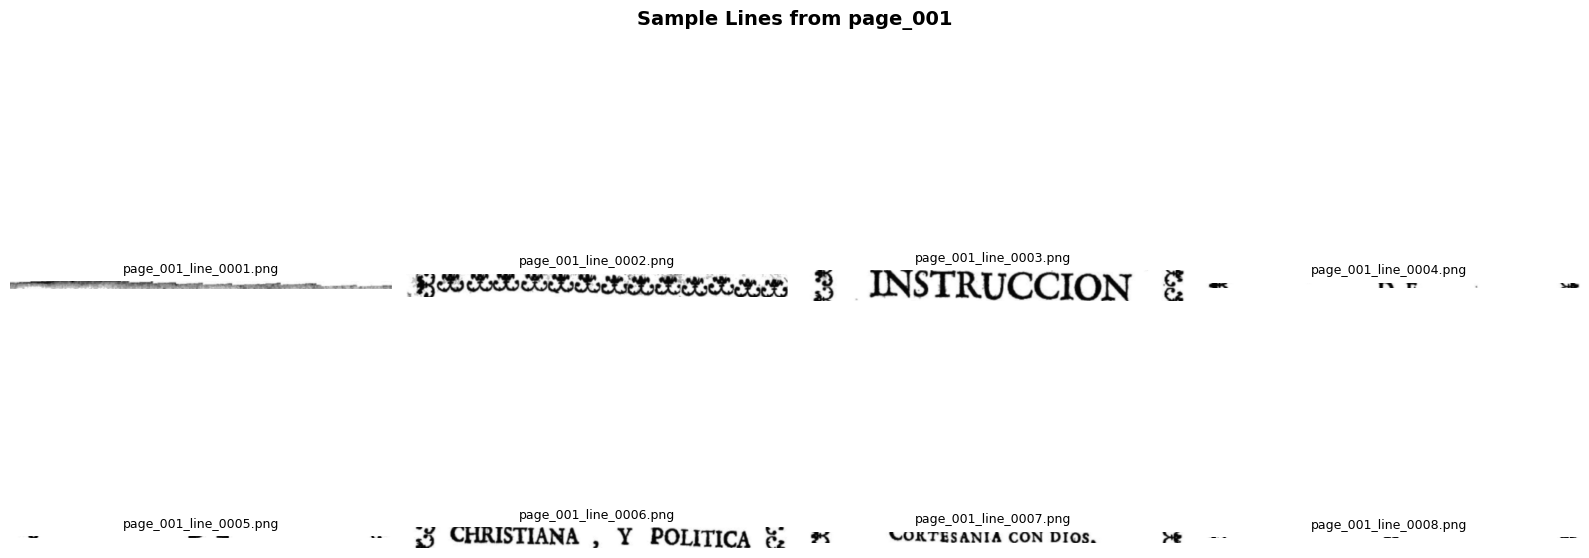

In [ ]:
print("\n" + "="*70)
print("SAMPLE OUTPUT PREVIEW")
print("="*70)

output_path = Path(OUTPUT_FOLDER)
page_folders = sorted(output_path.glob("page_*"))

if page_folders:
    first_page = page_folders[0]
    lines = sorted((first_page / "lines").glob("*.png"))[:8]
    
    if lines:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        
        fig.suptitle(f'Sample Lines from {first_page.name}', 
                    fontsize=14, fontweight='bold')
        
        for idx, line_file in enumerate(lines):
            ax = axes[idx]
            line_img = cv2.imread(str(line_file))
            ax.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
            ax.set_title(line_file.name, fontsize=9)
            ax.axis('off')
        
        # Hide unused
        for idx in range(len(lines), 8):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

# Crop lines page by page - Part 3

In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Output, Button, VBox, HBox, Label
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
from datetime import datetime
from tqdm import tqdm

print("✓ All imports successful!")
print("✓ Ready for interactive page-by-page processing")

✓ All imports successful!
✓ Ready for interactive page-by-page processing


In [ ]:
class InteractivePageProcessor:
    """
    Process pages one-by-one with parameter tuning
    Allows individual parameter adjustment per page
    """
    
    def __init__(self, input_folder, output_base):
        self.input_folder = Path(input_folder)
        self.output_base = Path(output_base)
        self.image_files = []
        
        # Current page state
        self.current_page_idx = 0
        self.current_img = None
        self.current_gray = None
        self.current_thresh = None
        self.current_lines = []
        self.current_hist = None
        
        # Store parameters per page
        self.page_parameters = {}
        
        # Create output directories
        self.output_base.mkdir(exist_ok=True, parents=True)
        
        self._find_images()
    
    def _find_images(self):
        """Find all image files in folder"""
        image_extensions = ['.png', '.jpg', '.jpeg', '.tiff', '.bmp']
        
        for ext in image_extensions:
            self.image_files.extend(self.input_folder.glob(f"**/*{ext}"))
            self.image_files.extend(self.input_folder.glob(f"**/*{ext.upper()}"))
        
        self.image_files = sorted(list(set(self.image_files)))
        
        print(f"\n✓ Found {len(self.image_files)} images")
        for i, img_file in enumerate(self.image_files, 1):
            print(f"  {i}. {img_file.name}")
    
    def load_page(self, page_idx):
        """Load specific page"""
        if page_idx < 0 or page_idx >= len(self.image_files):
            print(f"❌ Invalid page index: {page_idx}")
            return False
        
        self.current_page_idx = page_idx
        image_file = self.image_files[page_idx]
        
        # Load image
        self.current_img = cv2.imread(str(image_file))
        if self.current_img is None:
            print(f"❌ Cannot read: {image_file}")
            return False
        
        # Preprocess
        self.current_gray = cv2.cvtColor(self.current_img, cv2.COLOR_BGR2GRAY)
        _, self.current_thresh = cv2.threshold(
            self.current_gray, 0, 255, 
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )
        
        print(f"✓ Loaded page {page_idx + 1}/{len(self.image_files)}: {image_file.name}")
        print(f"  Size: {self.current_img.shape}")
        
        return True
    
    def detect_lines(self, threshold_percent=0.10, min_gap=5, min_line_height=5):
        """Detect lines with current parameters"""
        if self.current_thresh is None:
            return [], None
        
        # Horizontal projection
        hist = np.sum(self.current_thresh, axis=1)
        self.current_hist = hist
        
        max_hist = np.max(hist)
        if max_hist == 0:
            return [], hist
        
        threshold = max_hist * threshold_percent
        text_rows = np.where(hist > threshold)[0]
        
        if len(text_rows) == 0:
            return [], hist
        
        # Detect lines
        lines = []
        start = None
        
        for i, val in enumerate(hist):
            if val > threshold and start is None:
                start = i
            elif val <= threshold and start is not None:
                gap = i - start
                if gap >= min_line_height:
                    lines.append((start, i))
                start = None
        
        if start is not None:
            last_gap = len(hist) - start
            if last_gap >= min_line_height:
                lines.append((start, len(hist)))
        
        # Merge nearby lines
        if min_gap > 1:
            merged = []
            for y_start, y_end in lines:
                if merged and y_start - merged[-1][1] < min_gap:
                    merged[-1] = (merged[-1][0], y_end)
                else:
                    merged.append((y_start, y_end))
            lines = merged
        
        self.current_lines = lines
        return lines, hist
    
    def get_current_page_info(self):
        """Get info about current page"""
        if self.current_page_idx >= len(self.image_files):
            return None
        
        return {
            'page_num': self.current_page_idx + 1,
            'total_pages': len(self.image_files),
            'filename': self.image_files[self.current_page_idx].name,
            'size': self.current_img.shape if self.current_img is not None else None
        }
    
    def save_page_lines(self, page_params=None):
        """Save current page lines to organized folder"""
        if not self.current_lines or self.current_img is None:
            print("❌ No lines to save")
            return 0
        
        page_info = self.get_current_page_info()
        page_name = f"page_{page_info['page_num']:03d}"
        
        # Create page folder
        page_folder = self.output_base / page_name
        page_folder.mkdir(exist_ok=True, parents=True)
        
        lines_dir = page_folder / "lines"
        metadata_dir = page_folder / "metadata"
        
        lines_dir.mkdir(exist_ok=True, parents=True)
        metadata_dir.mkdir(exist_ok=True, parents=True)
        
        # Save each line
        saved_count = 0
        line_details = []
        
        for line_num, (y1, y2) in enumerate(self.current_lines, 1):
            try:
                # Crop line (NO PADDING)
                line_img = self.current_img[int(y1):int(y2), :]
                
                if line_img.shape[0] == 0 or line_img.shape[1] == 0:
                    continue
                
                # Normalize height only
                target_height = 64
                current_height = line_img.shape[0]
                current_width = line_img.shape[1]
                
                ratio = target_height / current_height
                new_width = int(current_width * ratio)
                
                line_img_normalized = cv2.resize(
                    line_img, (new_width, target_height),
                    interpolation=cv2.INTER_AREA
                )
                
                # Save image
                img_filename = f"{page_name}_line_{line_num:04d}.png"
                img_path = lines_dir / img_filename
                cv2.imwrite(str(img_path), line_img_normalized)
                
                # Save metadata
                metadata = {
                    'page_number': page_info['page_num'],
                    'page_name': page_name,
                    'line_number': line_num,
                    'source_image': page_info['filename'],
                    'original_position': {
                        'y_start': int(y1),
                        'y_end': int(y2),
                        'height': int(y2 - y1)
                    },
                    'original_dimensions': [current_height, current_width],
                    'normalized_dimensions': list(line_img_normalized.shape),
                    'resize_ratio': float(ratio),
                    'saved_file': img_filename,
                    'parameters_used': page_params,
                    'created_at': datetime.now().isoformat()
                }
                
                meta_filename = f"{page_name}_line_{line_num:04d}.json"
                meta_path = metadata_dir / meta_filename
                
                with open(meta_path, 'w') as f:
                    json.dump(metadata, f, indent=2)
                
                line_details.append(metadata)
                saved_count += 1
            
            except Exception as e:
                print(f"❌ Error saving line {line_num}: {e}")
        
        # Save page summary
        page_summary = {
            'page_number': page_info['page_num'],
            'page_name': page_name,
            'source_image': page_info['filename'],
            'source_path': str(self.image_files[self.current_page_idx]),
            'image_size': [self.current_img.shape[1], self.current_img.shape[0]],
            'total_lines_detected': len(self.current_lines),
            'lines_saved': saved_count,
            'output_directory': str(page_folder),
            'line_heights': [int(y2 - y1) for y1, y2 in self.current_lines],
            'parameters_used': page_params,
            'line_details': line_details,
            'created_at': datetime.now().isoformat()
        }
        
        summary_path = page_folder / "page_summary.json"
        with open(summary_path, 'w') as f:
            json.dump(page_summary, f, indent=2)
        
        # Store parameters for this page
        self.page_parameters[page_name] = page_params
        
        return saved_count

print("✓ InteractivePageProcessor class created")

✓ InteractivePageProcessor class created


In [ ]:
# Change this to your book folder
INPUT_FOLDER =r"data\Buendia_Instruccion\cropped"
OUTPUT_FOLDER =r"tests\output"

print(f"\n📂 Input folder:  {INPUT_FOLDER}")
print(f"📂 Output folder: {OUTPUT_FOLDER}")

# Create processor
processor = InteractivePageProcessor(INPUT_FOLDER, OUTPUT_FOLDER)

print(f"\n✓ Ready to process {len(processor.image_files)} pages")


📂 Input folder:  C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\Buendia_Instruccion\cropped
📂 Output folder: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\tests\output

✓ Found 64 images
  1. Book1_page_0001_col_5.png
  2. Book1_page_0002_col_0.png
  3. Book1_page_0003_col_0.png
  4. Book1_page_0003_col_1.png
  5. Book1_page_0004_col_0.png
  6. Book1_page_0004_col_1.png
  7. Book1_page_0005_col_0.png
  8. Book1_page_0005_col_2.png
  9. Book1_page_0006_col_0.png
  10. Book1_page_0006_col_1.png
  11. Book1_page_0007_col_0.png
  12. Book1_page_0007_col_1.png
  13. Book1_page_0008_col_0.png
  14. Book1_page_0008_col_1.png
  15. Book1_page_0009_col_0.png
  16. Book1_page_0009_col_1.png
  17. Book1_page_0010_col_0.png
  18. Book1_page_0010_col_1.png
  19. Book1_page_0011_col_0.png
  20. Book1_page_0011_col_1.png
  21. Book1_page_0013_col_0.png
  22. Book1_page_0013_col_1.png
  23. Book1_page_0014_col_0.png
 

In [ ]:
# Load first page
processor.load_page(0)

page_info = processor.get_current_page_info()
print(f"\n✓ Current page: {page_info['page_num']}/{page_info['total_pages']}")

✓ Loaded page 1/64: Book1_page_0001_col_5.png
  Size: (6000, 2902, 3)

✓ Current page: 1/64


In [ ]:
print("\n" + "="*70)
print("STEP 1: TUNE PARAMETERS FOR CURRENT PAGE")
print("="*70)
print("\nAdjust sliders to optimize line detection for this page\n")

# Store current params for this page
current_params = {
    'threshold': 0.10,
    'min_gap': 5,
    'min_height': 5
}

def update_page_preview(threshold_percent=0.10, min_gap=5, min_line_height=5):
    """Update preview with new parameters"""
    global current_params
    
    current_params = {
        'threshold': threshold_percent,
        'min_gap': min_gap,
        'min_height': min_line_height
    }
    
    # Detect lines
    lines, hist = processor.detect_lines(
        threshold_percent, min_gap, min_line_height
    )
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Page {processor.get_current_page_info()["page_num"]}/{processor.get_current_page_info()["total_pages"]}: {processor.get_current_page_info()["filename"]}',
                fontsize=14, fontweight='bold')
    
    # 1. Image with detected lines (RED)
    ax = axes[0]
    img_display = cv2.cvtColor(processor.current_img, cv2.COLOR_BGR2RGB).copy()
    
    for i, (y1, y2) in enumerate(lines):
        cv2.rectangle(img_display, (0, int(y1)), (img_display.shape[1], int(y2)),
                     (255, 0, 0), 2)  # RED
    
    ax.imshow(img_display)
    ax.set_title(f'Detected Lines: {len(lines)}', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # 2. Projection with threshold
    ax = axes[1]
    ax.plot(hist, range(len(hist)), linewidth=2, color='#3498db')
    ax.fill_betweenx(range(len(hist)), 0, hist, alpha=0.3, color='#3498db')
    
    max_hist = np.max(hist)
    threshold = max_hist * threshold_percent
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=3,
              label=f'Threshold ({threshold_percent:.1%})', alpha=0.8)
    
    for y1, y2 in lines:
        ax.axhline(y=y1, color='red', linestyle='-', alpha=0.2, linewidth=0.8)
    
    ax.set_title('Horizontal Projection (RED THRESHOLD)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Count', fontsize=10)
    ax.set_ylabel('Row', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.legend()
    
    # 3. Statistics
    ax = axes[2]
    ax.axis('off')
    
    if lines:
        heights = np.array([y2 - y1 for y1, y2 in lines])
        stats_text = f"""
PAGE DETECTION RESULTS
{'='*35}

Lines Detected:  {len(lines)}
Avg Height:      {np.mean(heights):.1f} px
Min Height:      {np.min(heights):.0f} px
Max Height:      {np.max(heights):.0f} px
Std Dev:         {np.std(heights):.1f} px

PARAMETERS
{'='*35}

Threshold:       {threshold_percent:.1%}
Min Gap:         {min_gap} px
Min Height:      {min_line_height} px

COVERAGE
{'='*35}

Total Text:      {np.sum(heights):.0f} px
Page Height:     {processor.current_img.shape[0]} px
Coverage:        {(np.sum(heights)/processor.current_img.shape[0]*100):.1f}%
        """
    else:
        stats_text = """
NO LINES DETECTED

Adjust:
• Lower threshold
• Reduce min_height
• Adjust min_gap
        """
    
    ax.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
           verticalalignment='center', bbox=dict(boxstyle='round',
           facecolor='#ffcccc', alpha=0.8, edgecolor='red', linewidth=2))
    
    plt.tight_layout()
    plt.show()

# Interactive sliders
interact(update_page_preview,
         threshold_percent=FloatSlider(min=0.01, max=0.50, step=0.01, value=0.10,
                                      description='Threshold %:',
                                      style={'description_width': '120px'},
                                      layout=widgets.Layout(width='500px')),
         min_gap=IntSlider(min=1, max=20, step=1, value=5,
                          description='Min Gap:',
                          style={'description_width': '120px'},
                          layout=widgets.Layout(width='500px')),
         min_line_height=IntSlider(min=1, max=50, step=1, value=5,
                                  description='Min Height:',
                                  style={'description_width': '120px'},
                                  layout=widgets.Layout(width='500px'))
);

print("\n✓ Use sliders above to adjust parameters")
print("✓ When satisfied with preview, go to STEP 2")


STEP 1: TUNE PARAMETERS FOR CURRENT PAGE

Adjust sliders to optimize line detection for this page



interactive(children=(FloatSlider(value=0.1, description='Threshold %:', layout=Layout(width='500px'), max=0.5…


✓ Use sliders above to adjust parameters
✓ When satisfied with preview, go to STEP 2


In [ ]:
print("\n" + "="*70)
print("STEP 2: SAVE LINES FOR CURRENT PAGE")
print("="*70)

# Detect lines with final parameters
lines, hist = processor.detect_lines(
    current_params['threshold'],
    current_params['min_gap'],
    current_params['min_height']
)

print(f"\n📄 Page {processor.get_current_page_info()['page_num']}: {len(lines)} lines detected")

# Save lines
saved_count = processor.save_page_lines(current_params)

print(f"✓ Saved {saved_count} lines")
print(f"✓ Output: {processor.output_base}/page_{processor.get_current_page_info()['page_num']:03d}/")


STEP 2: SAVE LINES FOR CURRENT PAGE

📄 Page 1: 25 lines detected
✓ Saved 25 lines
✓ Output: C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\tests\output/page_001/



SAVED LINES PREVIEW


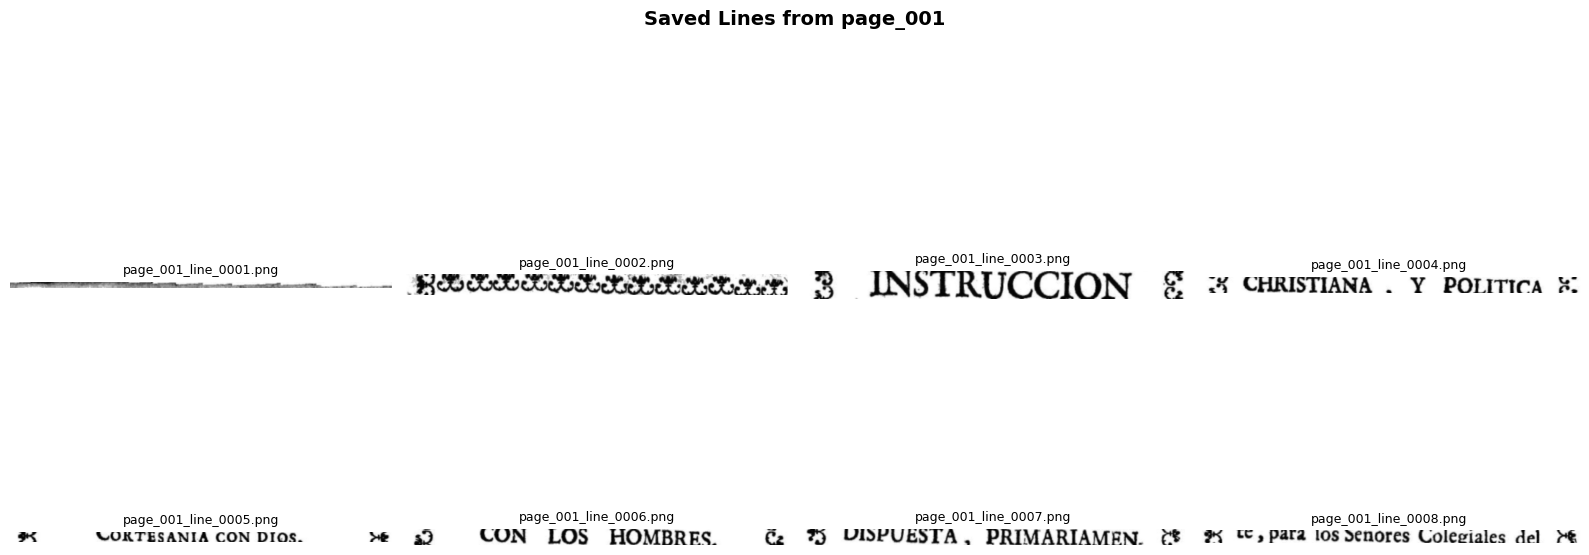

✓ Saved 8 lines shown above


In [ ]:
print("\n" + "="*70)
print("SAVED LINES PREVIEW")
print("="*70)

page_name = f"page_{processor.get_current_page_info()['page_num']:03d}"
page_folder = processor.output_base / page_name
lines_dir = page_folder / "lines"

saved_lines = sorted(lines_dir.glob("*.png"))[:8]

if saved_lines:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    fig.suptitle(f'Saved Lines from {page_name}', fontsize=14, fontweight='bold')
    
    for idx, line_file in enumerate(saved_lines):
        ax = axes[idx]
        line_img = cv2.imread(str(line_file))
        ax.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
        ax.set_title(line_file.name, fontsize=9)
        ax.axis('off')
    
    for idx in range(len(saved_lines), 8):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print(f"✓ Saved {len(saved_lines)} lines shown above")

In [ ]:
print("\n" + "="*70)
print("STEP 3: MOVE TO NEXT PAGE")
print("="*70)

# Move to next page
next_page_idx = processor.current_page_idx + 1

if next_page_idx < len(processor.image_files):
    processor.load_page(next_page_idx)
    page_info = processor.get_current_page_info()
    
    print(f"\n✓ Moved to next page")
    print(f"  Current: {page_info['page_num']}/{page_info['total_pages']}")
    print(f"  File: {page_info['filename']}")
    print(f"  Size: {page_info['size']}")
    
    print(f"\n→ Go back to CELL 5 to tune parameters for this page")
    print(f"→ Then CELL 6 to save lines")
    print(f"→ Then CELL 7 to preview")
    print(f"→ Then CELL 8 to move to next page")
else:
    print(f"\n✓ All pages processed!")
    print(f"  Total pages: {len(processor.image_files)}")


STEP 3: MOVE TO NEXT PAGE
✓ Loaded page 2/29: line_0002.png
  Size: (146, 2801, 3)

✓ Moved to next page
  Current: 2/29
  File: line_0002.png
  Size: (146, 2801, 3)

→ Go back to CELL 5 to tune parameters for this page
→ Then CELL 6 to save lines
→ Then CELL 7 to preview
→ Then CELL 8 to move to next page


In [ ]:
print("\n" + "="*70)
print("BATCH PROCESSING SUMMARY")
print("="*70)

output_path = Path(OUTPUT_FOLDER)
page_folders = sorted(output_path.glob("page_*"))

print(f"\n✓ Pages processed: {len(page_folders)}/{len(processor.image_files)}")

# Collect statistics
total_lines = 0
page_stats = []

for page_folder in page_folders:
    page_summary_file = page_folder / "page_summary.json"
    if page_summary_file.exists():
        with open(page_summary_file, 'r') as f:
            page_data = json.load(f)
        
        num_lines = page_data['lines_saved']
        page_stats.append({
            'page': page_data['page_name'],
            'lines': num_lines,
            'file': page_data['source_image']
        })
        total_lines += num_lines

# Print table
print(f"\n{'Page':<12} {'Lines':<10} {'File':<30}")
print("-" * 55)
for stat in page_stats:
    print(f"{stat['page']:<12} {stat['lines']:<10} {stat['file']:<30}")

print("-" * 55)
print(f"{'TOTAL':<12} {total_lines:<10}")

# Create batch summary
batch_summary = {
    'total_pages': len(page_folders),
    'total_lines': total_lines,
    'pages_processed': len(page_folders),
    'pages_remaining': len(processor.image_files) - len(page_folders),
    'page_details': page_stats,
    'output_folder': str(output_path),
    'timestamp': datetime.now().isoformat()
}

batch_summary_path = output_path / "BATCH_SUMMARY.json"
with open(batch_summary_path, 'w') as f:
    json.dump(batch_summary, f, indent=2)

print(f"\n✓ Summary saved to {batch_summary_path}")


BATCH PROCESSING SUMMARY

✓ Pages processed: 1/29

Page         Lines      File                          
-------------------------------------------------------
page_001     1          line_0001.png                 
-------------------------------------------------------
TOTAL        1         

✓ Summary saved to BATCH_SUMMARY.json
